### 1. Estimated Regression Line
$$
\hat{y} = b_0 + b_1 x
$$

### 3. Slope Coefficient
$$
b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$

Alternative form:
$$
b_1 = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}
$$

### 4. Intercept
$$
b_0 = \bar{y} - b_1 \bar{x}
$$


<math display="block">\begin{align}
 \widehat\alpha & = \bar{y} - \widehat\beta\,\bar{x}, \\[5pt]
  \widehat\beta &= \frac{ \sum_{i=1}^n \left(x_i - \bar{x}\right) \left(y_i - \bar{y}\right) }{ \sum_{i=1}^n \left(x_i - \bar{x}\right)^2 }
            = \frac{ \sum_{i=1}^n \Delta x_i \Delta y_i }{ \sum_{i=1}^n \Delta x_i^2 } 
\end{align}</math>

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
housing = pd.read_csv("data.csv")
housing.shape

(7278, 7)

In [7]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [14]:
from sklearn import linear_model
LR_model = linear_model.LinearRegression()

x_train = np.asanyarray(train_set[["size"]])
y_train = np.asanyarray(train_set[["price"]])

LR_model.fit(x_train, y_train)

theta1 = LR_model.coef_[0][0]
theta0 = LR_model.intercept_[0]
# theta1, theta0
print(f"{theta1}")
print(f"{theta0}")

797.7600812318601
-2010.5609497361802


Text(0, 0.5, 'Price')

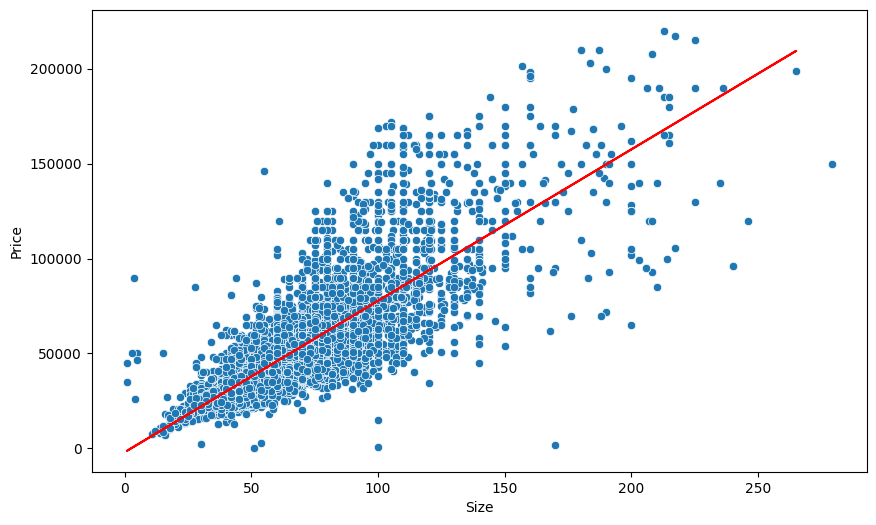

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=housing, x='size', y='price')
plt.plot(x_train, theta1*x_train + theta0, '-r')
plt.xlabel("Size")
plt.ylabel("Price")

In [19]:
x_test = np.asanyarray(test_set[['size']])
y_test = np.asanyarray(test_set[['price']])

In [20]:
y_predict = LR_model.predict(x_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=12314.311243983144
RMSE=np.float64(18185.08796554313)
